## Task 5: Personal Loan Acceptance Prediction (Bank Marketing Dataset)

**Objective:** Predict which bank customers are likely to subscribe to a term
deposit / accept a personal offer, based on demographic, financial, and
campaign-contact attributes.

**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository, via Kaggle)
- 11,162 rows, 17 columns
- Target variable: `deposit` (yes = customer subscribed, no = customer declined)

**Approach:**
1. Load and explore the data
2. Perform basic data exploration on features such as age, job, and marital status
3. Clean and prepare the data (handle 'unknown' categories, drop leakage-prone features)
4. Encode categorical variables
5. Train Logistic Regression, Decision Tree, and Random Forest classifiers
6. Evaluate using accuracy, confusion matrix, and classification report
7. Quantify the impact of the `duration` data-leakage column
8. Analyze which customer groups are more likely to accept the offer

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [2]:
# Load the dataset
df = pd.read_csv('E:/DevelopersHub Internship/Task_5/bank.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (11162, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
# Dataset info and summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


## Basic Data Exploration

Per the task instructions, we start by exploring key features: age, job, and
marital status, alongside checking data quality (missing values, duplicates,
and the special `'unknown'` category used in several columns instead of a
true null).

In [5]:
# Check for missing values and duplicate rows
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Duplicate rows: 0


In [6]:
# Several categorical columns use the literal string 'unknown' instead of NaN.
# We check how common this is before deciding how to handle it.
print("'unknown' value counts per column:\n")
for col in df.select_dtypes(include='object').columns:
    cnt = (df[col] == 'unknown').sum()
    if cnt > 0:
        print(f"{col}: {cnt} ({cnt / len(df) * 100:.1f}%)")

'unknown' value counts per column:

job: 70 (0.6%)
education: 497 (4.5%)
contact: 2346 (21.0%)
poutcome: 8326 (74.6%)


In [7]:
# Target variable balance
print("Deposit (target) distribution:")
print(df['deposit'].value_counts())
print("\nPercentage:")
print(df['deposit'].value_counts(normalize=True).mul(100).round(2))

Deposit (target) distribution:
no     5873
yes    5289
Name: deposit, dtype: int64

Percentage:
no     52.62
yes    47.38
Name: deposit, dtype: float64


## Data Cleaning & Preparation

**Important note on `duration`:** the call `duration` is only known *after*
a call has taken place, so it leaks information about the outcome (very long
calls are strongly associated with "yes"). For a realistic model that could
be used *before* making a call — i.e. to decide *who to call* — we drop
`duration` from our main modeling dataset. We keep a separate copy of the
data **with** `duration` included, purely to demonstrate later how much of
the "accuracy" in many online tutorials on this dataset comes from this one
leaky column, rather than from genuinely predictive features.

We also treat `pdays = -1` (customer never contacted before a previous
campaign) by creating a clearer flag, since -1 is a placeholder rather than a
true numeric value.

In [8]:
# Keep a copy of the dataset WITH duration, for a later leakage comparison
df_with_duration = df.copy()

# Drop duration from the main dataset to avoid data leakage (only known after the call is made)
df = df.drop(columns=['duration'])

# Create a flag for customers who were never previously contacted (pdays == -1)
df['was_contacted_before'] = (df['pdays'] != -1).astype(int)
df_with_duration['was_contacted_before'] = (df_with_duration['pdays'] != -1).astype(int)

print("Shape after cleaning (no duration):", df.shape)
df[['pdays', 'was_contacted_before']].head()

Shape after cleaning (no duration): (11162, 17)


,pdays,was_contacted_before
0,-1,0
1,-1,0
2,-1,0
3,-1,0
4,-1,0


## Exploratory Data Analysis (EDA)

We now visualize how age, job, marital status, and other features relate to
whether a customer accepted the offer.

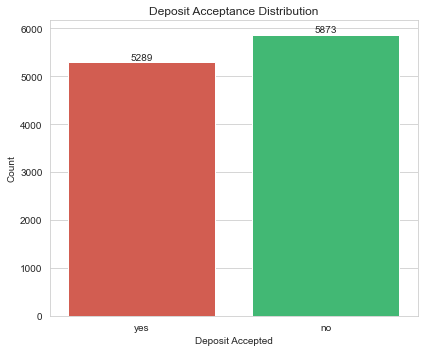

In [9]:
# EDA: Target distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='deposit', palette=['#e74c3c', '#2ecc71'])
plt.title('Deposit Acceptance Distribution')
plt.xlabel('Deposit Accepted')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

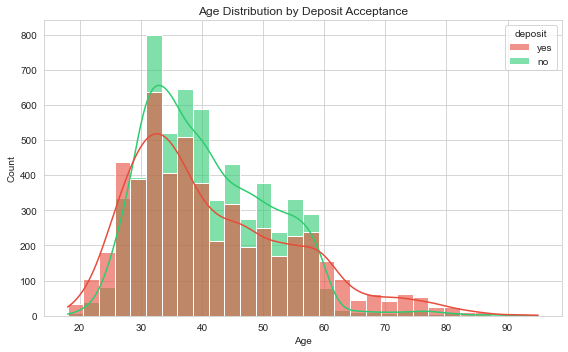

In [10]:
# EDA: Age distribution by deposit acceptance
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='deposit', bins=30, kde=True,
             palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title('Age Distribution by Deposit Acceptance')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

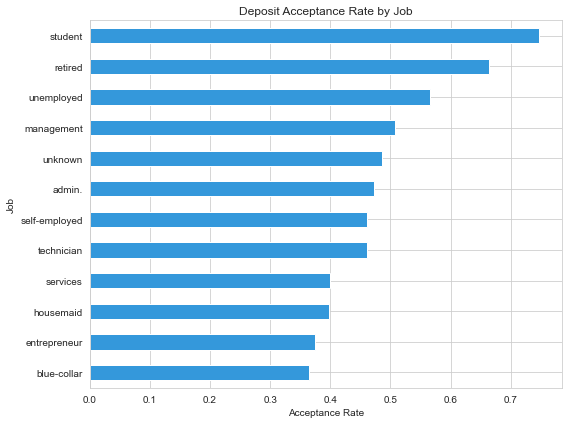

In [11]:
# EDA: Job vs Deposit acceptance rate
job_rate = df.groupby('job')['deposit'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
job_rate.plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Deposit Acceptance Rate by Job')
plt.xlabel('Acceptance Rate')
plt.ylabel('Job')
plt.tight_layout()
plt.show()

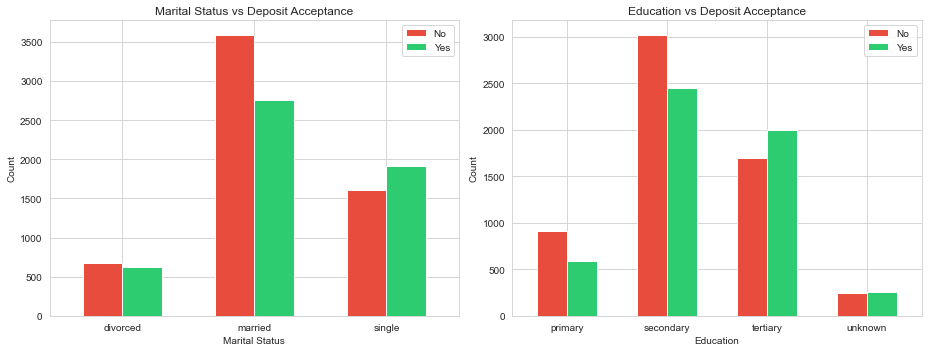

In [12]:
# EDA: Marital status vs Deposit acceptance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

marital_counts = df.groupby(['marital', 'deposit']).size().unstack()
marital_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.6)
axes[0].set_title('Marital Status vs Deposit Acceptance')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No', 'Yes'])

education_counts = df.groupby(['education', 'deposit']).size().unstack()
education_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.6)
axes[1].set_title('Education vs Deposit Acceptance')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No', 'Yes'])

plt.tight_layout()
plt.show()

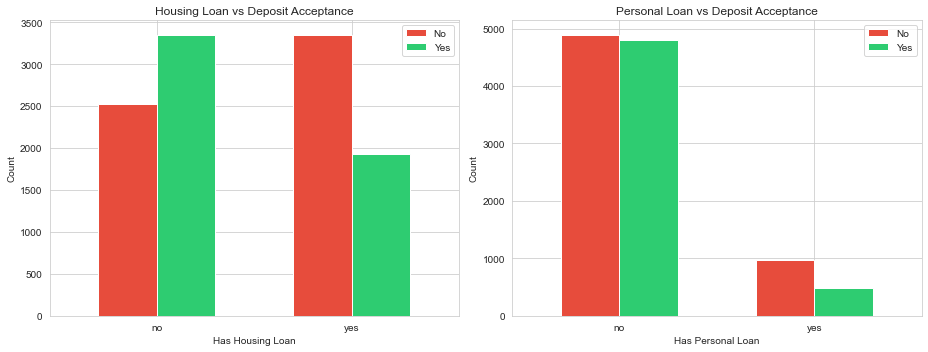

In [13]:
# EDA: Housing loan and personal loan vs Deposit acceptance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

housing_counts = df.groupby(['housing', 'deposit']).size().unstack()
housing_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.6)
axes[0].set_title('Housing Loan vs Deposit Acceptance')
axes[0].set_xlabel('Has Housing Loan')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No', 'Yes'])

loan_counts = df.groupby(['loan', 'deposit']).size().unstack()
loan_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.6)
axes[1].set_title('Personal Loan vs Deposit Acceptance')
axes[1].set_xlabel('Has Personal Loan')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No', 'Yes'])

plt.tight_layout()
plt.show()

<Figure size 504x360 with 0 Axes>

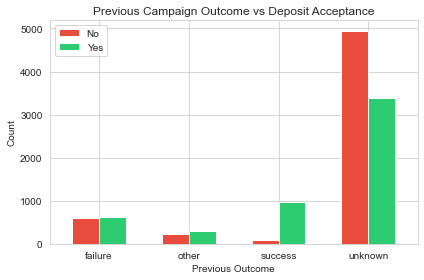

In [14]:
# EDA: Previous campaign outcome vs Deposit acceptance
plt.figure(figsize=(7, 5))
poutcome_counts = df.groupby(['poutcome', 'deposit']).size().unstack()
poutcome_counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.6)
plt.title('Previous Campaign Outcome vs Deposit Acceptance')
plt.xlabel('Previous Outcome')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

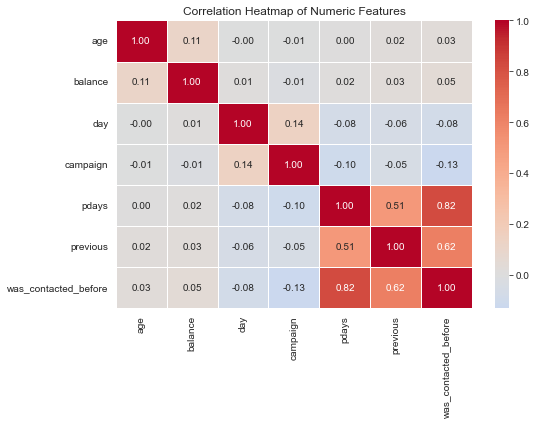

In [15]:
# EDA: Correlation heatmap of numeric features
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Encoding Categorical Features

Binary columns (`default`, `housing`, `loan`, `deposit`) are label encoded.
Multi-category columns (`job`, `marital`, `education`, `contact`, `month`,
`poutcome`) are one-hot encoded since they have no inherent order.

In [16]:
# Label Encoding for binary columns
binary_cols = ['default', 'housing', 'loan', 'deposit']
le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Binary encodings:")
for col, mapping in le_dict.items():
    print(f"  {col}: {mapping}")

# One-Hot Encoding for multi-category columns
multi_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("\nShape after encoding:", df.shape)

Binary encodings:
  default: {'no': 0, 'yes': 1}
  housing: {'no': 0, 'yes': 1}
  loan: {'no': 0, 'yes': 1}
  deposit: {'no': 0, 'yes': 1}

Shape after encoding: (11162, 43)


## Model Training

We split the data into features (X) and target (y), scale numeric features,
and train three classifiers: Logistic Regression, Decision Tree, and Random
Forest. All three are trained **without** `duration`, so these are our
realistic, deployable results.

In [17]:
# Split features and target
X = df.drop(columns=['deposit'])
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set shape: (8929, 42)
Test set shape: (2233, 42)


In [18]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, log_preds)
print(f"Logistic Regression Accuracy: {log_acc:.4f}")

Logistic Regression Accuracy: 0.6950


In [19]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_preds)
print(f"Decision Tree Accuracy: {dt_acc:.4f}")

Decision Tree Accuracy: 0.6932


In [20]:
# Train Random Forest (a stronger ensemble model, still without duration)
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.7250


## Model Evaluation

We compare all three models using confusion matrices and classification
reports.

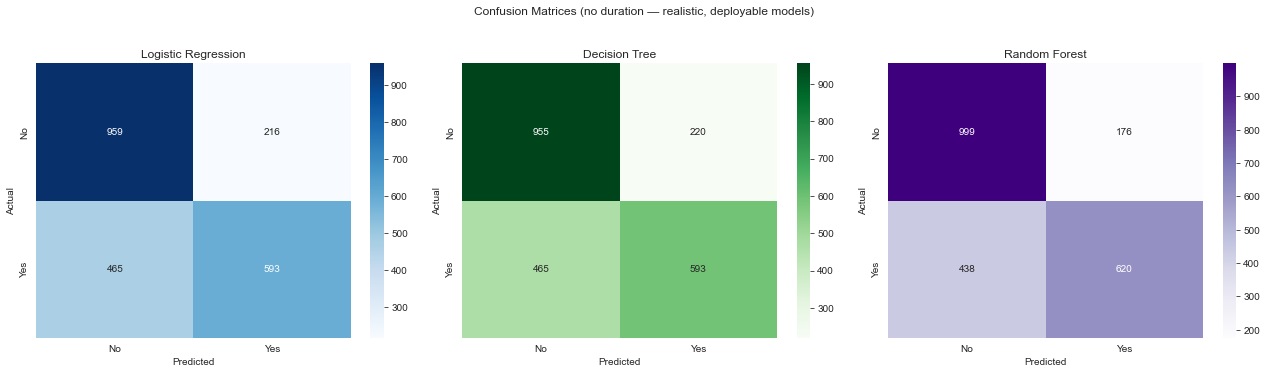

In [21]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_log = confusion_matrix(y_test, log_preds)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_dt = confusion_matrix(y_test, dt_preds)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[2].set_title('Random Forest')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Confusion Matrices (no duration — realistic, deployable models)', y=1.03)
plt.tight_layout()
plt.show()

In [22]:
print("Classification Report — Logistic Regression\n")
print(classification_report(y_test, log_preds, target_names=['No', 'Yes']))

print("\nClassification Report — Decision Tree\n")
print(classification_report(y_test, dt_preds, target_names=['No', 'Yes']))

print("\nClassification Report — Random Forest\n")
print(classification_report(y_test, rf_preds, target_names=['No', 'Yes']))

Classification Report — Logistic Regression

              precision    recall  f1-score   support

          No       0.67      0.82      0.74      1175
         Yes       0.73      0.56      0.64      1058

    accuracy                           0.70      2233
   macro avg       0.70      0.69      0.69      2233
weighted avg       0.70      0.70      0.69      2233


Classification Report — Decision Tree

              precision    recall  f1-score   support

          No       0.67      0.81      0.74      1175
         Yes       0.73      0.56      0.63      1058

    accuracy                           0.69      2233
   macro avg       0.70      0.69      0.68      2233
weighted avg       0.70      0.69      0.69      2233


Classification Report — Random Forest

              precision    recall  f1-score   support

          No       0.70      0.85      0.76      1175
         Yes       0.78      0.59      0.67      1058

    accuracy                           0.73      2233
   

                 Model  Accuracy
0  Logistic Regression  0.695029
1        Decision Tree  0.693238
2        Random Forest  0.725034


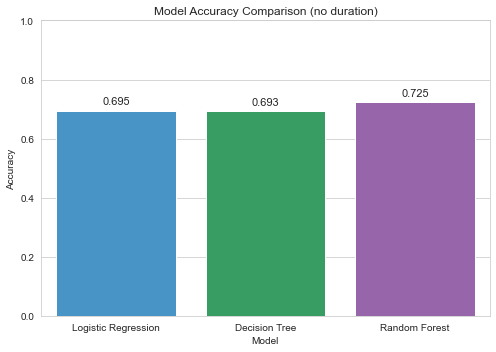

In [23]:
# Accuracy comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_acc, dt_acc, rf_acc]
})
print(comparison)

plt.figure(figsize=(7, 5))
sns.barplot(data=comparison, x='Model', y='Accuracy', palette=['#3498db', '#27ae60', '#9b59b6'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison (no duration)')
for i, acc in enumerate(comparison['Accuracy']):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Feature Importance & Business Insight

Using the Random Forest model (our best-performing, leakage-free model), we
identify which features most strongly influence whether a customer accepts
the offer, then translate this into which customer groups are the best
targets for future campaigns.

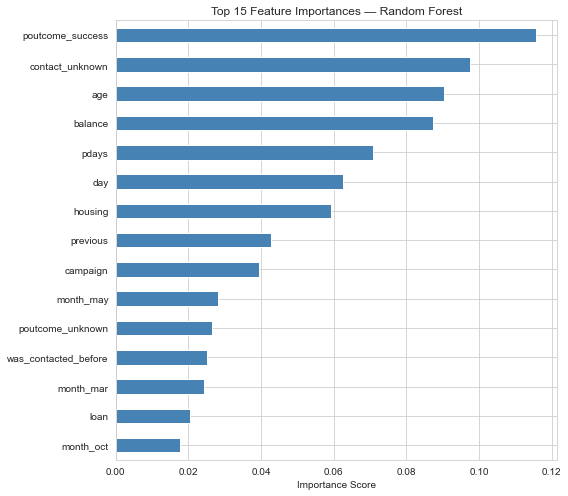

In [24]:
# Feature Importance (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [25]:
# Business insight: acceptance rate by previous campaign outcome
# (poutcome_counts was computed earlier in the EDA section, before encoding)
poutcome_rate = poutcome_counts.div(poutcome_counts.sum(axis=1), axis=0)
print("Acceptance rate by previous campaign outcome:")
print(poutcome_rate['yes'].round(3))

Acceptance rate by previous campaign outcome:
poutcome
failure    0.503
other      0.572
success    0.913
unknown    0.407
Name: yes, dtype: float64


## Why Is Accuracy "Only" ~70%? A Note on Data Leakage

It's natural to expect higher accuracy, and many public notebooks on this
exact dataset report 85%+ — but that's almost always because they leave the
`duration` column in. `duration` is the length of the *sales call itself*,
which is only known *after* the call has already happened. A model trained
on it isn't really predicting "will this customer accept an offer" — it's
mostly just learning "long calls tend to end in a yes," which is true but
useless for deciding *who to call in the first place*.

To make this concrete, we train the same three models **with** `duration`
included, purely for comparison.

In [26]:
# Re-encode the duration-included copy the same way as the main dataset
df_dur = df_with_duration.copy()

binary_cols = ['default', 'housing', 'loan', 'deposit']
for col in binary_cols:
    le = LabelEncoder()
    df_dur[col] = le.fit_transform(df_dur[col])

multi_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_dur = pd.get_dummies(df_dur, columns=multi_cols, drop_first=True)

X_dur = df_dur.drop(columns=['deposit'])
y_dur = df_dur['deposit']

X_train_dur, X_test_dur, y_train_dur, y_test_dur = train_test_split(
    X_dur, y_dur, test_size=0.2, random_state=42, stratify=y_dur
)

scaler_dur = StandardScaler()
X_train_dur_scaled = scaler_dur.fit_transform(X_train_dur)
X_test_dur_scaled = scaler_dur.transform(X_test_dur)

# Logistic Regression WITH duration
log_dur = LogisticRegression(max_iter=1000, random_state=42)
log_dur.fit(X_train_dur_scaled, y_train_dur)
log_dur_acc = accuracy_score(y_test_dur, log_dur.predict(X_test_dur_scaled))

# Decision Tree WITH duration
dt_dur = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_dur.fit(X_train_dur, y_train_dur)
dt_dur_acc = accuracy_score(y_test_dur, dt_dur.predict(X_test_dur))

# Random Forest WITH duration
rf_dur = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf_dur.fit(X_train_dur, y_train_dur)
rf_dur_acc = accuracy_score(y_test_dur, rf_dur.predict(X_test_dur))

print(f"WITH duration — Logistic Regression Accuracy: {log_dur_acc:.4f}")
print(f"WITH duration — Decision Tree Accuracy:       {dt_dur_acc:.4f}")
print(f"WITH duration — Random Forest Accuracy:       {rf_dur_acc:.4f}")

WITH duration — Logistic Regression Accuracy: 0.8262
WITH duration — Decision Tree Accuracy:       0.8133
WITH duration — Random Forest Accuracy:       0.8459


                 Model  Without duration (realistic)  With duration (leaked)
0  Logistic Regression                      0.695029                0.826243
1        Decision Tree                      0.693238                0.813256
2        Random Forest                      0.725034                0.845947


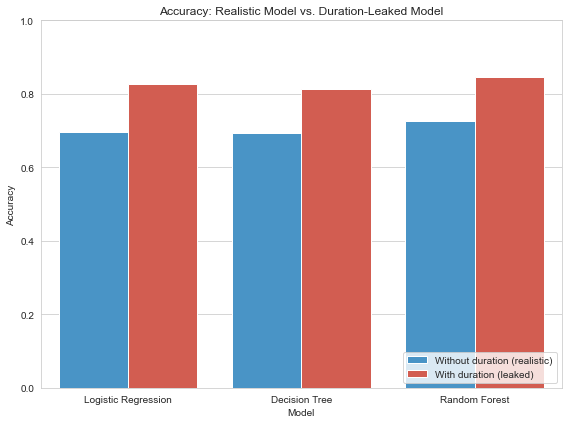

In [27]:
# Side-by-side comparison: with vs without duration
leak_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Without duration (realistic)': [log_acc, dt_acc, rf_acc],
    'With duration (leaked)': [log_dur_acc, dt_dur_acc, rf_dur_acc]
})
print(leak_comparison)

leak_melted = leak_comparison.melt(id_vars='Model', var_name='Setup', value_name='Accuracy')

plt.figure(figsize=(8, 6))
sns.barplot(data=leak_melted, x='Model', y='Accuracy', hue='Setup',
            palette=['#3498db', '#e74c3c'])
plt.ylim(0, 1)
plt.title('Accuracy: Realistic Model vs. Duration-Leaked Model')
plt.ylabel('Accuracy')
plt.legend(title='', loc='lower right')
plt.tight_layout()
plt.show()

## Conclusion & Key Insights

### Data Insights:
- The dataset had no true missing values, but several columns (`job`,
  `education`, `contact`, `poutcome`) used the literal category `'unknown'`
  instead of a null — this was kept as its own category rather than
  imputed, since "unknown" can itself be informative (e.g. customers with
  unknown contact type behave differently from those with a known one).
- The `duration` column was set aside for the main models because it is only
  known *after* a call takes place, so including it would leak the outcome.
  We quantify exactly how much this matters in the dedicated comparison
  section below.
- The target classes are reasonably balanced (~53% no / ~47% yes), so
  accuracy is a reasonably reliable metric here, unlike in more imbalanced
  churn-style problems.

### Feature Insights:
1. **Previous campaign outcome is the single strongest predictor.** Customers
   whose previous campaign outcome was "success" accept at a 91.3% rate,
   versus ~50.3% for "failure" and just 40.7% for "unknown" outcomes.
2. **Age has a U-shaped relationship with acceptance.** Acceptance is
   highest for 18–25 year-olds (71.1%) and 65+ year-olds (80.4%), and lowest
   for the 35–55 working-age range (~41–42%).
3. **Job type matters.** Students (74.7%) and retirees (66.3%) accept most
   often; blue-collar (36.4%) and entrepreneur (37.5%) segments accept least.
4. **Existing financial commitments reduce acceptance.** Customers with a
   housing loan accept at 36.6% vs. 57.0% for those without one; customers
   with a personal loan accept at 33.2% vs. 49.5% for those without one.
5. **Being previously contacted at all (`was_contacted_before`)** is
   associated with a much higher acceptance rate (67.1%) than customers
   being reached for the first time (40.7%), confirming that warm leads
   convert far better than cold ones.

### Model Performance:
- Without `duration` (the realistic, deployable setup), **Random Forest was
  the strongest model at 72.5% accuracy**, ahead of Logistic Regression
  (69.5%) and Decision Tree (69.3%).
- The Random Forest's feature importance plot shows **`poutcome_success`**
  as by far the most influential feature, followed by **`contact_unknown`**,
  **`housing`**, and **`balance`**. Age and job ranked lower in raw
  importance for the tree-based models, but still showed clear, consistent
  patterns in the EDA acceptance-rate breakdowns above.
- Recall for the "Yes" class (56–59%) is noticeably lower than for "No"
  (81–85%) across all three models, meaning they're all better at confirming
  who will decline than at catching every likely acceptor — useful to know
  if the bank wants to maximize how many genuine acceptors get contacted.

### Why Accuracy Looks "Low" Compared to Some Tutorials:
- Many public notebooks on this exact dataset report accuracy in the
  85–87% range. The gap is almost entirely explained by the `duration`
  column (length of the sales call), which is **only known after the call
  has already happened**.
- When we re-ran all three models *with* `duration` included, accuracy
  jumped to 82.6% (Logistic Regression), 81.3% (Decision Tree), and 84.6%
  (Random Forest) — a 9–12 point gain purely from one leaked feature.
- That higher number is real, but it answers a different question
  ("did this call go well?") than the one the business actually needs
  answered ("who should we call in the first place?"). Our realistic
  72.5% Random Forest result is the more honest, more useful number for
  building an actual outbound-calling target list.

### Business Recommendation:
The bank should prioritize re-contacting customers who had a successful
outcome in a previous campaign, and focus new outreach on students,
retirees, and customers without existing housing or personal loans. Customers
who already declined or have heavy existing debt are lower-priority targets
and may be better served with a different offer or contact strategy.